# Exercise 3. 네트워크 이상탐지 — 완전 실습
NSL-KDD를 사용해 Isolation Forest, LOF, One-Class SVM을 비교합니다. `binary_label`과 `label`은 학습에 사용하지 않고 **사후 평가에만** 사용합니다.

In [1]:
# ============================================================
# 1번째 코드 셀: 네트워크 이상탐지 실습 코드 상세 설명
# ============================================================

# 실행에 영향을 주지 않는 경고 메시지를 관리하기 위해 warnings 모듈을 불러옵니다.
import warnings, os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt

# 실습 화면을 복잡하게 만드는 경고 메시지를 숨깁니다.
warnings.filterwarnings("ignore")
# 아래 명령을 실행하여 현재 단계의 데이터 처리 또는 분석을 수행합니다.
from IPython.display import display
# 실행할 때마다 동일한 결과가 나오도록 난수 기준값을 고정합니다.
RANDOM_STATE=42
# NumPy에서 생성되는 난수도 동일하게 재현되도록 고정합니다.
np.random.seed(RANDOM_STATE)
# 데이터프레임을 출력할 때 표시되는 행이나 열의 개수를 조정합니다.
pd.set_option("display.max_columns",100)
# 현재 처리 결과를 사용자가 확인할 수 있도록 화면에 출력합니다.
print("환경 준비 완료")

환경 준비 완료


In [2]:
# ============================================================
# 2번째 코드 셀: 네트워크 이상탐지 실습 코드 상세 설명
# ============================================================

# 자동으로 찾을 CSV 파일 이름에 포함된 핵심 단어를 지정합니다.
EXPECTED_KEYWORD="nsl_kdd_sample"
# 지정한 폴더에서 CSV 파일 목록을 검색합니다.
paths=(glob.glob("/content/*.csv")+glob.glob("/content/drive/MyDrive/**/*.csv",recursive=True)
       # 지정한 폴더에서 CSV 파일 목록을 검색합니다.
       +glob.glob("./*.csv")+glob.glob("/mnt/data/*.csv"))
# 검색된 파일 중 핵심 단어가 포함된 파일만 선택합니다.
matched=[p for p in paths if EXPECTED_KEYWORD.lower() in os.path.basename(p).lower()]
# 자동으로 파일을 찾지 못했을 때만 직접 업로드를 실행합니다.
if not matched:
    # 아래 명령을 실행하여 현재 단계의 데이터 처리 또는 분석을 수행합니다.
    from google.colab import files
    # 현재 처리 결과를 사용자가 확인할 수 있도록 화면에 출력합니다.
    print("CSV 파일을 업로드하세요.")
    # Colab의 파일 선택 창을 열어 사용자가 CSV 파일을 업로드하게 합니다.
    uploaded=files.upload()
    # 검색된 파일 중 핵심 단어가 포함된 파일만 선택합니다.
    matched=list(uploaded.keys())
# 찾은 파일 중 첫 번째 파일의 경로를 저장합니다.
file_path=matched[0]
# CSV 파일을 읽어 pandas 데이터프레임으로 변환합니다.
df=pd.read_csv(file_path)
# 현재 처리 결과를 사용자가 확인할 수 있도록 화면에 출력합니다.
print("파일:",file_path,"크기:",df.shape)
# 데이터가 정상적으로 불러와졌는지 앞부분을 표로 확인합니다.
display(df.head())

CSV 파일을 업로드하세요.


Saving Exercise3. nsl_kdd_sample.csv to Exercise3. nsl_kdd_sample.csv
파일: Exercise3. nsl_kdd_sample.csv 크기: (3000, 44)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,binary_label
0,0,tcp,bgp,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,217,2,1.0,1.0,0.0,0.0,0.01,0.07,0.0,255,2,0.01,0.08,0.00,0.00,1.0,1.0,0.0,0.00,neptune,19,attack
1,0,tcp,ftp_data,SF,201,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.0,0.0,0.0,1.00,0.00,0.0,94,70,0.19,0.76,0.18,0.03,0.0,0.0,0.7,0.01,normal,21,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,119,14,1.0,1.0,0.0,0.0,0.12,0.08,0.0,255,20,0.08,0.07,0.00,0.00,1.0,1.0,0.0,0.00,neptune,21,attack
3,0,tcp,http,S1,235,21900,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,2,1.0,0.5,0.0,0.0,1.00,0.00,1.0,255,255,1.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,normal,20,normal
4,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,289,5,1.0,1.0,0.0,0.0,0.02,0.06,0.0,255,7,0.03,0.08,0.00,0.00,1.0,1.0,0.0,0.00,neptune,21,attack


## 1. 데이터 이해

In [3]:
# ============================================================
# 3번째 코드 셀: 네트워크 이상탐지 실습 코드 상세 설명
# ============================================================

# 행 수, 컬럼 이름, 자료형, 결측값 여부 등 데이터 구조를 확인합니다.
print(df.info()); print("중복:",df.duplicated().sum())

# 컬럼별 결측값 개수를 계산합니다.
display(df.isnull().sum().sort_values(ascending=False).head(10).to_frame("결측치"))

# 각 범주가 데이터에 몇 번 등장하는지 개수를 계산합니다.
display(df["binary_label"].value_counts().to_frame("개수"))

# 각 범주가 데이터에 몇 번 등장하는지 개수를 계산합니다.
display(df["label"].value_counts().head(15).to_frame("세부공격"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     3000 non-null   int64  
 1   protocol_type                3000 non-null   object 
 2   service                      3000 non-null   object 
 3   flag                         3000 non-null   object 
 4   src_bytes                    3000 non-null   int64  
 5   dst_bytes                    3000 non-null   int64  
 6   land                         3000 non-null   int64  
 7   wrong_fragment               3000 non-null   int64  
 8   urgent                       3000 non-null   int64  
 9   hot                          3000 non-null   int64  
 10  num_failed_logins            3000 non-null   int64  
 11  logged_in                    3000 non-null   int64  
 12  num_compromised              3000 non-null   int64  
 13  root_shell        

,결측치
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


,개수
binary_label,
attack,1500
normal,1500


,세부공격
label,
normal,1500
neptune,1066
ipsweep,90
satan,86
portsweep,83
smurf,63
nmap,33
warezclient,30
back,23


## 2. 전처리와 PCA
범주형은 One-Hot Encoding, 수치형은 표준화합니다. PCA는 이상탐지 모델이 아니라 차원 축소 기법입니다.

In [4]:
# ============================================================
# 4번째 코드 셀: 네트워크 이상탐지 실습 코드 상세 설명
# ============================================================

# 수치형과 범주형 컬럼에 서로 다른 전처리를 적용합니다.
from sklearn.compose import ColumnTransformer

# 변수마다 단위가 다른 문제를 줄이기 위해 값을 표준화합니다.
from sklearn.preprocessing import OneHotEncoder,StandardScaler

# 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.
from sklearn.impute import SimpleImputer

# 전처리와 모델 학습 단계를 정해진 순서로 묶어 한 번에 실행합니다.
from sklearn.pipeline import Pipeline

# 아래 명령을 실행하여 현재 단계의 데이터 처리 또는 분석을 수행합니다.
from sklearn.decomposition import PCA

# 완전히 동일한 중복 행을 제거하고 행 번호를 다시 정리합니다.
data=df.drop_duplicates().reset_index(drop=True)

# 계산하거나 선택한 결과를 이후 단계에서 사용할 변수에 저장합니다.
true_label = data["binary_label"].map({"normal": 0, "attack": 1})
attack_type = data["label"]

# 모델 학습에 사용하지 않을 식별자 또는 정답 컬럼을 제거합니다.
X=data.drop(columns=["label","binary_label","difficulty"])

# 숫자로 저장된 수치형 컬럼만 선택합니다.
num=X.select_dtypes(include=np.number).columns; cat=X.select_dtypes(exclude=np.number).columns

# 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.
prep=ColumnTransformer([("num",Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler())]),num),

# 비어 있는 결측값을 지정한 대표값으로 채우는 전처리 도구입니다.
("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]),cat)])

# 전처리 기준을 학습한 뒤 실제 데이터까지 변환합니다.
X_processed = prep.fit_transform(X)
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_reduced = pca.fit_transform(X_processed)

# 현재 처리 결과를 사용자가 확인할 수 있도록 화면에 출력합니다.
print("원본 데이터 크기:", X.shape)
print("전처리 후 크기:", X_processed.shape)
print("PCA 후 크기:", X_reduced.shape)
print("PCA 누적 설명분산:", pca.explained_variance_ratio_.sum())

원본 데이터 크기: (3000, 41)
전처리 후 크기: (3000, 109)
PCA 후 크기: (3000, 22)
PCA 누적 설명분산: 0.9578568828246431


## 3. 이상탐지 모델을 하나씩 실행

이번 실습에서는 반복문이나 모델 배열을 사용하지 않습니다.

각 모델을 다음 순서로 하나씩 실행합니다.

1. 모델 생성
2. 모델 학습 및 예측
3. 예측값을 정상 0, 이상 1로 변환
4. 이상 점수 계산
5. 평가지표 확인

세 모델의 결과를 각각 직접 확인합니다.

### 3-1. Isolation Forest

Isolation Forest는 다른 데이터와 쉽게 분리되는 데이터를 이상치로 판단합니다.

In [5]:
# ============================================================
# Isolation Forest 모델 생성·학습·예측
# ============================================================

# Isolation Forest 모델을 불러옵니다.
from sklearn.ensemble import IsolationForest

# Isolation Forest 모델을 생성합니다.
isolation_forest = IsolationForest(
    n_estimators=200,      # 의사결정나무를 200개 사용합니다.
    contamination=0.1,     # 전체 데이터 중 약 10%를 이상치로 판단하도록 설정합니다.
    random_state=RANDOM_STATE,  # 실행할 때마다 같은 결과가 나오도록 고정합니다.
    n_jobs=-1              # 가능한 CPU 코어를 모두 사용합니다.
)

# fit_predict()로 모델 학습과 예측을 한 번에 수행합니다.
#
# Isolation Forest의 원래 예측값:
#  1  → 정상
# -1  → 이상
isolation_raw_prediction = isolation_forest.fit_predict(X_reduced)

# 교육과 평가를 쉽게 하기 위해 예측값을 변환합니다.
#
# 정상 1  → 0
# 이상 -1 → 1
isolation_prediction = (
    isolation_raw_prediction == -1
).astype(int)

# score_samples()는 각 데이터의 정상 정도를 점수로 반환합니다.
#
# 원래 점수는 값이 작을수록 이상에 가깝습니다.
# 해석을 쉽게 하기 위해 앞에 마이너스(-)를 붙입니다.
#
# 변환 후에는 값이 클수록 이상한 데이터입니다.
isolation_score = -isolation_forest.score_samples(
    X_reduced
)
print("Isolation Forest 예측 완료")
print("정상으로 예측한 데이터 수:", (isolation_prediction == 0).sum())
print("이상으로 예측한 데이터 수:", (isolation_prediction == 1).sum())

Isolation Forest 예측 완료
정상으로 예측한 데이터 수: 2700
이상으로 예측한 데이터 수: 300


### 3-2. Local Outlier Factor

LOF는 주변 데이터와 비교했을 때 밀도가 크게 다른 데이터를 이상치로 판단합니다.

In [6]:
# ============================================================
# Local Outlier Factor 모델 생성·학습·예측
# ============================================================

# Local Outlier Factor 모델을 불러옵니다.
from sklearn.neighbors import LocalOutlierFactor

# LOF 모델을 생성합니다.
lof_model = LocalOutlierFactor(
    n_neighbors=20,        # 각 데이터를 주변 20개 이웃과 비교합니다.
    contamination=0.1      # 전체 데이터 중 약 10%를 이상치로 판단합니다.
)

# fit_predict()로 모델 학습과 예측을 한 번에 수행합니다.
#
# LOF의 원래 예측값:
#  1  → 정상
# -1  → 이상
lof_raw_prediction = lof_model.fit_predict(
    X_reduced
)

# 정상은 0, 이상은 1로 변환합니다.
lof_prediction = (
    lof_raw_prediction == -1
).astype(int)

# negative_outlier_factor_는 LOF가 계산한 이상 정도입니다.
#
# 원래는 값이 작을수록 이상에 가깝습니다.
# 앞에 마이너스(-)를 붙여 값이 클수록 이상하도록 바꿉니다.
lof_score = -lof_model.negative_outlier_factor_

print("LOF 예측 완료")
print("정상으로 예측한 데이터 수:", (lof_prediction == 0).sum())
print("이상으로 예측한 데이터 수:", (lof_prediction == 1).sum())

LOF 예측 완료
정상으로 예측한 데이터 수: 2700
이상으로 예측한 데이터 수: 300


### 3-3. One-Class SVM

One-Class SVM은 대부분의 데이터가 들어가는 정상 영역의 경계를 만들고, 경계 밖의 데이터를 이상치로 판단합니다.

In [7]:
# ============================================================
# One-Class SVM 모델 생성·학습·예측
# ============================================================

# One-Class SVM 모델을 불러옵니다.
from sklearn.svm import OneClassSVM

# One-Class SVM 모델을 생성합니다.
oneclass_svm = OneClassSVM(
    kernel="rbf",   # 비선형 경계를 만들기 위해 RBF 커널을 사용합니다.
    gamma="scale",  # 입력 데이터 크기에 맞춰 gamma 값을 자동 설정합니다.
    nu=0.1          # 이상치 비율을 약 10%로 가정합니다.
)

# fit_predict()로 모델 학습과 예측을 한 번에 수행합니다.
#
# One-Class SVM의 원래 예측값:
#  1  → 정상
# -1  → 이상
svm_raw_prediction = oneclass_svm.fit_predict(
    X_reduced
)

# 정상은 0, 이상은 1로 변환합니다.
svm_prediction = (
    svm_raw_prediction == -1
).astype(int)

# decision_function()은 데이터가 정상 영역에서
# 얼마나 안쪽 또는 바깥쪽에 있는지 계산합니다.
#
# 원래 값은 작을수록 이상에 가깝습니다.
# 앞에 마이너스(-)를 붙여 값이 클수록 이상하도록 바꿉니다.
svm_score = -oneclass_svm.decision_function(
    X_reduced
)

print("One-Class SVM 예측 완료")
print("정상으로 예측한 데이터 수:", (svm_prediction == 0).sum())
print("이상으로 예측한 데이터 수:", (svm_prediction == 1).sum())

One-Class SVM 예측 완료
정상으로 예측한 데이터 수: 2704
이상으로 예측한 데이터 수: 296


## 4. 모델별 성능을 하나씩 평가

실제 정답인 `binary_label`은 모델 학습에 사용하지 않았습니다.  
각 모델의 예측이 얼마나 정확한지 확인할 때만 사용합니다.

In [8]:
# ============================================================
# 평가에 필요한 함수 불러오기
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay
)

### 4-1. Isolation Forest 평가

In [9]:
# Isolation Forest 정확도를 계산합니다.
isolation_accuracy = accuracy_score(
    true_label,
    isolation_prediction
)

# Isolation Forest 정밀도를 계산합니다.
isolation_precision = precision_score(
    true_label,
    isolation_prediction,
    zero_division=0
)

# Isolation Forest 재현율을 계산합니다.
isolation_recall = recall_score(
    true_label,
    isolation_prediction,
    zero_division=0
)

# Isolation Forest F1 점수를 계산합니다.
isolation_f1 = f1_score(
    true_label,
    isolation_prediction,
    zero_division=0
)

# Isolation Forest ROC-AUC를 계산합니다.
isolation_roc_auc = roc_auc_score(
    true_label,
    isolation_score
)

# Isolation Forest PR-AUC를 계산합니다.
isolation_pr_auc = average_precision_score(
    true_label,
    isolation_score
)

print("Isolation Forest 평가 결과")
print("Accuracy :", round(isolation_accuracy, 4))
print("Precision:", round(isolation_precision, 4))
print("Recall   :", round(isolation_recall, 4))
print("F1-score :", round(isolation_f1, 4))
print("ROC-AUC  :", round(isolation_roc_auc, 4))
print("PR-AUC   :", round(isolation_pr_auc, 4))

Isolation Forest 평가 결과
Accuracy : 0.5207
Precision: 0.6033
Recall   : 0.1207
F1-score : 0.2011
ROC-AUC  : 0.3592
PR-AUC   : 0.4846


### 4-2. LOF 평가

In [10]:
# LOF 정확도를 계산합니다.
lof_accuracy = accuracy_score(
    true_label,
    lof_prediction
)

# LOF 정밀도를 계산합니다.
lof_precision = precision_score(
    true_label,
    lof_prediction,
    zero_division=0
)

# LOF 재현율을 계산합니다.
lof_recall = recall_score(
    true_label,
    lof_prediction,
    zero_division=0
)

# LOF F1 점수를 계산합니다.
lof_f1 = f1_score(
    true_label,
    lof_prediction,
    zero_division=0
)

# LOF ROC-AUC를 계산합니다.
lof_roc_auc = roc_auc_score(
    true_label,
    lof_score
)

# LOF PR-AUC를 계산합니다.
lof_pr_auc = average_precision_score(
    true_label,
    lof_score
)

print("LOF 평가 결과")
print("Accuracy :", round(lof_accuracy, 4))
print("Precision:", round(lof_precision, 4))
print("Recall   :", round(lof_recall, 4))
print("F1-score :", round(lof_f1, 4))
print("ROC-AUC  :", round(lof_roc_auc, 4))
print("PR-AUC   :", round(lof_pr_auc, 4))

LOF 평가 결과
Accuracy : 0.476
Precision: 0.38
Recall   : 0.076
F1-score : 0.1267
ROC-AUC  : 0.4173
PR-AUC   : 0.4432


### 4-3. One-Class SVM 평가

In [11]:
# One-Class SVM 정확도를 계산합니다.
svm_accuracy = accuracy_score(
    true_label,
    svm_prediction
)

# One-Class SVM 정밀도를 계산합니다.
svm_precision = precision_score(
    true_label,
    svm_prediction,
    zero_division=0
)

# One-Class SVM 재현율을 계산합니다.
svm_recall = recall_score(
    true_label,
    svm_prediction,
    zero_division=0
)

# One-Class SVM F1 점수를 계산합니다.
svm_f1 = f1_score(
    true_label,
    svm_prediction,
    zero_division=0
)

# One-Class SVM ROC-AUC를 계산합니다.
svm_roc_auc = roc_auc_score(
    true_label,
    svm_score
)

# One-Class SVM PR-AUC를 계산합니다.
svm_pr_auc = average_precision_score(
    true_label,
    svm_score
)

print("One-Class SVM 평가 결과")
print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1-score :", round(svm_f1, 4))
print("ROC-AUC  :", round(svm_roc_auc, 4))
print("PR-AUC   :", round(svm_pr_auc, 4))

One-Class SVM 평가 결과
Accuracy : 0.5267
Precision: 0.6351
Recall   : 0.1253
F1-score : 0.2094
ROC-AUC  : 0.8446
PR-AUC   : 0.7639


## 5. 세 모델 결과 비교

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,One-Class SVM,0.5267,0.6351,0.1253,0.2094,0.8446,0.7639
1,Isolation Forest,0.5207,0.6033,0.1207,0.2011,0.3592,0.4846
2,LOF,0.4760,0.3800,0.0760,0.1267,0.4173,0.4432


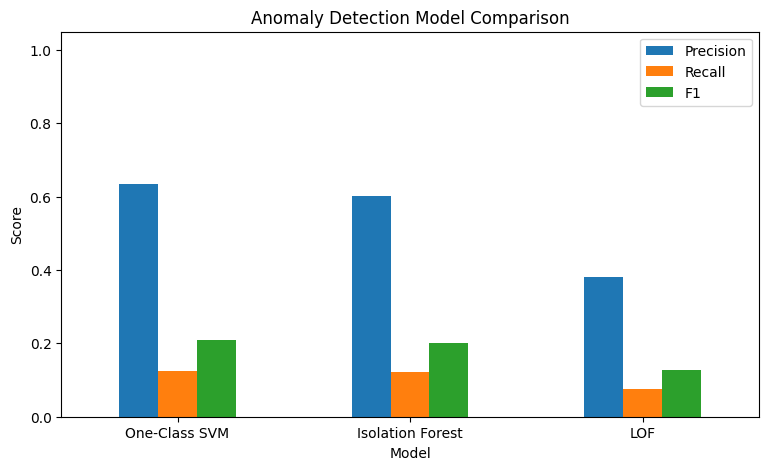

In [12]:
# 세 모델의 결과를 직접 입력하여 비교표를 만듭니다.
comparison_result = pd.DataFrame([
    {
        "Model": "Isolation Forest",
        "Accuracy": isolation_accuracy,
        "Precision": isolation_precision,
        "Recall": isolation_recall,
        "F1": isolation_f1,
        "ROC_AUC": isolation_roc_auc,
        "PR_AUC": isolation_pr_auc
    },
    {
        "Model": "LOF",
        "Accuracy": lof_accuracy,
        "Precision": lof_precision,
        "Recall": lof_recall,
        "F1": lof_f1,
        "ROC_AUC": lof_roc_auc,
        "PR_AUC": lof_pr_auc
    },
    {
        "Model": "One-Class SVM",
        "Accuracy": svm_accuracy,
        "Precision": svm_precision,
        "Recall": svm_recall,
        "F1": svm_f1,
        "ROC_AUC": svm_roc_auc,
        "PR_AUC": svm_pr_auc
    }
])


# F1 점수가 높은 순서로 정렬합니다.
comparison_result = comparison_result.sort_values(
    "F1",
    ascending=False
).reset_index(drop=True)


display(comparison_result.round(4))


# Precision, Recall, F1을 막대그래프로 비교합니다.
comparison_result.set_index("Model")[
    ["Precision", "Recall", "F1"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Anomaly Detection Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

## 6. Isolation Forest 결과 상세 확인

이후의 혼동행렬, 공격 유형별 탐지율, 시각화는 가장 이해하기 쉬운 **Isolation Forest 결과**를 사용합니다.

              precision    recall  f1-score   support

      normal     0.5115    0.9207    0.6576      1500
      attack     0.6033    0.1207    0.2011      1500

    accuracy                         0.5207      3000
   macro avg     0.5574    0.5207    0.4294      3000
weighted avg     0.5574    0.5207    0.4294      3000



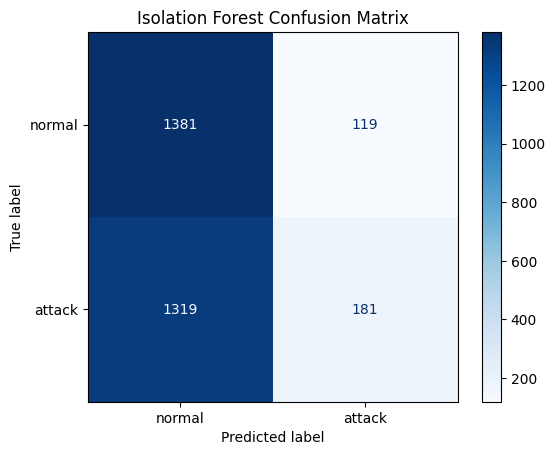

,Count,Detection_Rate,Mean_Anomaly_Score
label,,,
normal,1500,0.0793,0.3933
neptune,1066,0.0000,0.3513
ipsweep,90,0.1556,0.4566
satan,86,0.6163,0.4792
portsweep,83,0.4096,0.4933
smurf,63,0.6667,0.4942
nmap,33,0.0606,0.4330
warezclient,30,0.4333,0.5090
back,23,0.0000,0.3715


In [13]:
# Isolation Forest의 상세 분류 결과를 출력합니다.
print(
    classification_report(
        true_label,
        isolation_prediction,
        target_names=["normal", "attack"],
        digits=4
    )
)


# Isolation Forest의 혼동행렬을 그립니다.
ConfusionMatrixDisplay.from_predictions(
    true_label,
    isolation_prediction,
    display_labels=["normal", "attack"],
    cmap="Blues"
)

plt.title("Isolation Forest Confusion Matrix")
plt.show()


# 원본 데이터에 Isolation Forest의 예측과 이상 점수를 추가합니다.
inspection_data = data.copy()

inspection_data["anomaly_prediction"] = isolation_prediction
inspection_data["anomaly_score"] = isolation_score


# 공격 유형별 데이터 수, 탐지율, 평균 이상 점수를 계산합니다.
attack_detection_result = (
    inspection_data
    .groupby("label")
    .agg(
        Count=("label", "size"),
        Detection_Rate=("anomaly_prediction", "mean"),
        Mean_Anomaly_Score=("anomaly_score", "mean")
    )
    .sort_values("Count", ascending=False)
)


display(attack_detection_result.head(20).round(4))

## 7. Isolation Forest 결과 시각화

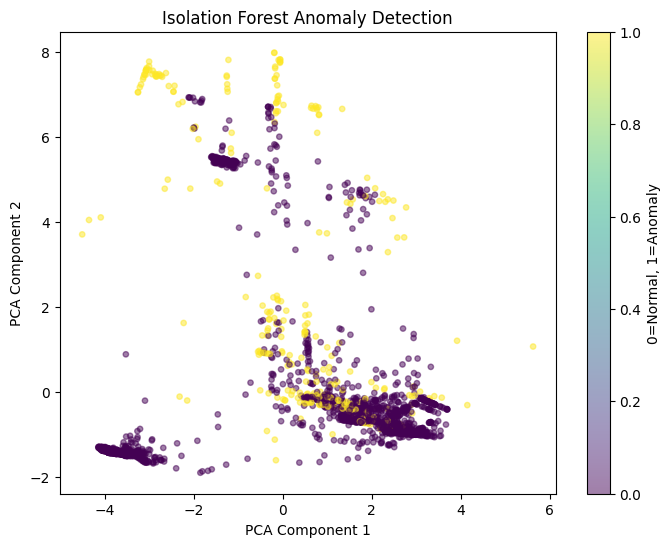

,protocol_type,service,flag,label,binary_label,anomaly_prediction,anomaly_score
2626,tcp,ftp,SF,satan,attack,1,0.713069
1870,tcp,telnet,SF,ipsweep,attack,1,0.709088
2742,tcp,ftp_data,SF,warezclient,attack,1,0.700215
2969,tcp,private,RSTR,portsweep,attack,1,0.694766
2787,tcp,private,RSTR,portsweep,attack,1,0.689754
1052,tcp,ftp_data,SF,warezclient,attack,1,0.688144
1570,tcp,telnet,SF,normal,normal,1,0.686863
255,tcp,ftp_data,SF,warezclient,attack,1,0.686133
2958,tcp,private,RSTR,portsweep,attack,1,0.682051
2441,tcp,private,RSTR,portsweep,attack,1,0.681820


In [14]:
# 많은 특성을 화면에 표시하기 위해 2차원으로 줄입니다.
pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)


# 전처리된 데이터를 2차원으로 변환합니다.
X_2d = pca_2d.fit_transform(
    X_processed
)


# 정상은 0, 이상은 1로 구분하여 산점도를 그립니다.
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=isolation_prediction,
    s=15,
    alpha=0.5
)

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="0=Normal, 1=Anomaly")
plt.show()


# 이상 점수가 높은 데이터 20개를 확인합니다.
top_anomalies = (
    inspection_data
    .sort_values("anomaly_score", ascending=False)
    [
        [
            "protocol_type",
            "service",
            "flag",
            "label",
            "binary_label",
            "anomaly_prediction",
            "anomaly_score"
        ]
    ]
    .head(20)
)


display(top_anomalies)

In [15]:
# Isolation Forest 결과가 추가된 데이터를 CSV로 저장합니다.
output_path = "/content/exercise3_anomaly_detection_results.csv"

inspection_data.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("결과 파일 저장 완료:", output_path)

결과 파일 저장 완료: /content/exercise3_anomaly_detection_results.csv
